In [1]:
import os
import numpy as np
import pandas as pd
import scipy

from IPython.display import display
from tqdm.auto import tqdm

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt

from src.data_utils import (
    remove_duplicate_texts,
    load_vader_words,
    load_gervader_words,
)

from src.preprocessing import run_preprocessing_loop

from src.model_utils import (
    vectorize,
    tune_lda_models,
    tune_lsa_models,
    build_sentiment_df,
    get_selected_topic_model,
    compute_dominant_topics,
    merge_topic_sentiment,
    build_topic_sentiment_summary
)

from src.visualization import (
    display_tuning_results,
    display_topic_model_summary,
    plot_topic_words,
    plot_topic_sizes,
    compare_topic_sizes,
    plot_topic_overlap_matrix,
    plot_topic_sentiment,
    show_reviews_for_topic
)

from src.styles import style_topic_sentiment

In [2]:
##########
# Data Import
##########

# Variable Definition
local_dir = "data"
path_reviews = f"{local_dir}/combined_reviews.csv"
stopword_path = "data/stopwords_custom.json"

# Import data to pandas dataframe
df_reviews = pd.read_csv(path_reviews)

df_reviews["language"] = df_reviews["origin"].map({
    "FragdenStaat": "de",
    "YELP": "en",
})

# Remove duplicate Requests
df_reviews = remove_duplicate_texts(df_reviews, text_col="review")


##########
# Stopword Definition
##########

# Import Sentiment Stopwords based on threshold
sia_en = SentimentIntensityAnalyzer()
de_thres = 2
en_thres = 1.5

vader_words_en = load_vader_words(sia_en, en_thres)
gervader_words_de = load_gervader_words("GerVADER/GERVaderLexicon.txt", de_thres)

# Build Basis-Dictionary
dict_stopw_default = {
    "iter_0": {
        "de_nltk_common": stopwords.words("german"),
        "de_vader_topic_only":gervader_words_de,
        "en_nltk_common": stopwords.words("english"),
        "en_vader_topic_only":vader_words_en,
        
    },
    "iter_1": {
        "de_custom_common": [],
        "de_custom_topic_only": [],
        "en_custom_common": [],
        "en_custom_topic_only": []
    }
}


=== Duplicate Removal ===
Before: 2000 rows
After:  1761 rows
Removed: 239 duplicates


In [3]:
##########
# Data PreProcessing
##########

top_n = 30       # Number of top tokens to display
n_process = 1    # Number of parallel processes (performance tuning)


# Run interactive preprocessing pipeline:
# - Loads or initializes stopword configuration (JSON)
# - Applies iterative stopword refinement (user-guided)
# - Cleans and tokenizes text for both topic modeling and sentiment analysis
# - Displays top token comparisons for validation
# - Repeats until user confirms final stopw

data_topic, data_sentiment, dict_stopw = run_preprocessing_loop(
    df_reviews=df_reviews,
    stopword_path=stopword_path,
    dict_stopw_default=dict_stopw_default,
    top_n=top_n,
    n_process=n_process
)


Stopword file found -> loading

Cleaning Data - Topic Modeling


Processing English: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:22<00:00, 45.09it/s]



Cleaning Data - Sentiment Analysis


Processing English: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:21<00:00, 45.53it/s]



Please review the top tokens and optionally extend them under 'iter_7' in data/stopwords_custom.json.
1 = JSON updated manually, start next iteration
2 = finished, continue with topic modeling


Selection:  2



Final stopwords applied. Proceeding to topic modeling.


In [4]:
############
# Create Vectors with BoW & TF-IDF
############

# Separate Pipelines: Topic Modeling vs. Sentiment
print("Creating Vectors - Topic Modeling")
vectors_topic = {}
vectors_topic["bow_by_lang"] = vectorize(CountVectorizer, data_topic)
vectors_topic["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_topic)

print("\nCreating Vectors - Sentiment Analysis")
vectors_sentiment = {}
vectors_sentiment["bow_by_lang"] = vectorize(CountVectorizer, data_sentiment)
vectors_sentiment["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_sentiment)

Creating Vectors - Topic Modeling
de: 760 Dokumente, 3699 Features
en: 1000 Dokumente, 2266 Features
de: 760 Dokumente, 3699 Features
en: 1000 Dokumente, 2266 Features

Creating Vectors - Sentiment Analysis
de: 760 Dokumente, 3840 Features
en: 1000 Dokumente, 2749 Features
de: 760 Dokumente, 3840 Features
en: 1000 Dokumente, 2749 Features


In [5]:
############
# LDA/BoW - Model Tuning (en|de)
############

# Perform LDA parameter tuning per language using Grid Search.
# Explores multiple configurations to identify optimal topic models
# for each language-specific dataset.

# -----------------------------
# CONFIGURATION
# -----------------------------

# Full parameter grid (production mode - slow but thorough)
lda_config_prod = {
    "topic_grid": [5, 10, 15, 20],   # number of topics to test
    "alpha_grid": [0.01, 0.1],       # document-topic prior (sparsity control)
    "eta_grid": [0.01, 0.1],         # topic-word prior
    "max_iter_grid": [10, 20],       # number of training iterations
    "random_states": [42],
    "learning_method": "batch",      # batch learning for stable convergence
}

# Minimal parameter grid (test mode - fast execution)
lda_config_test = {
    "topic_grid": [10],          # single topic value
    "alpha_grid": [0.1],         # single prior
    "eta_grid": [0.1],           # single prior
    "max_iter_grid": [10],       # minimal iterations
    "random_states": [42],
    "learning_method": "batch",
}

# -----------------------------
# SWITCH BETWEEN MODES
# -----------------------------

TEST_MODE = False  # set to False for full tuning, True for Test

lda_config = lda_config_test if TEST_MODE else lda_config_prod


# -----------------------------
# RUN TUNING
# -----------------------------

# Dictionary to store tuning results separately for each language
lda_tuning_results_by_lang = {}

# Iterate over language-specific BOW vectorized datasets
for lang, data in vectors_topic["bow_by_lang"].items():

    # Apply selected configuration (test or production)
    lda_tuning_results_by_lang[lang] = tune_lda_models(
        data=data,
        topic_grid=lda_config["topic_grid"],
        alpha_grid=lda_config["alpha_grid"],
        eta_grid=lda_config["eta_grid"],
        max_iter_grid=lda_config["max_iter_grid"],
        random_states=lda_config["random_states"],
        learning_method=lda_config["learning_method"],
        lang=lang
    )

LDA Tuning (en): 100%|██████████████████| 32/32 [05:17<00:00,  9.91s/it, k=20, iter=20, coh=0.61, std=0.000, perp=1943]


In [6]:
############
# LDA/BoW - Tuning Validation (en|de)
############

# Define evaluation configuration for LDA tuning results.
# Each metric includes:
# - col: column name in the tuning results
# - weight: contribution to overall score
# - higher_is_better: optimization direction
# - good_quantile / bad_quantile: thresholds for scoring normalization
# - format: display formatting
lda_tuning_config = [
    {"col": "coherence",               "weight": 0.30, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.2f}"},
    {"col": "coherence_std",           "weight": 0.10, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.2f}"},
    {"col": "perplexity",              "weight": 0.20, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "largest_topic_share",     "weight": 0.15, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "avg_word_overlap",        "weight": 0.10, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

# Evaluate and display LDA tuning results per language:
# - Computes weighted scores based on defined metrics
# - Ranks models by overall performance
# - Displays top configurations with formatted styling
lda_tuning_interpreted_by_lang = display_tuning_results(
    results_by_lang=lda_tuning_results_by_lang,
    tuning_config=lda_tuning_config,
    title="LDA/BoW Tuning",
    head_rows=15,  # Limit output to top-performing configurations
    hide_cols=[
        # Hide non-relevant or heavy columns for display clarity
        "topic_words", "topic_terms", "doc_topic_matrix", "model",
        "max_word_overlap", "largest_topic_share_std", "perplexity_std"
    ]
)


=== LDA/BoW Tuning (de) ===


,n_topics,alpha,eta,max_iter,coherence,coherence_std,perplexity,largest_topic_share,avg_word_overlap,best_seed,overall_score
26,20,0.010000,0.100000,10,2.20,0.00,1780.0307,0.1079,0.0085,42,0.7336
27,20,0.010000,0.100000,20,2.17,0.00,1760.0407,0.1092,0.0082,42,0.7270
31,20,0.100000,0.100000,20,2.16,0.00,1857.1077,0.1184,0.0076,42,0.7097
30,20,0.100000,0.100000,10,2.13,0.00,1893.6569,0.1171,0.0088,42,0.6836
19,15,0.010000,0.100000,20,2.08,0.00,1835.7553,0.1105,0.0098,42,0.6722
25,20,0.010000,0.010000,20,2.15,0.00,2331.2542,0.1066,0.0071,42,0.6434
18,15,0.010000,0.100000,10,2.07,0.00,1869.4638,0.1105,0.0138,42,0.6344
14,10,0.100000,0.100000,10,2.11,0.00,1990.7054,0.1618,0.0096,42,0.6262
29,20,0.100000,0.010000,20,2.12,0.00,2387.7852,0.1118,0.0067,42,0.6250
15,10,0.100000,0.100000,20,2.08,0.00,1955.5100,0.1671,0.0095,42,0.6198



=== LDA/BoW Tuning (en) ===


,n_topics,alpha,eta,max_iter,coherence,coherence_std,perplexity,largest_topic_share,avg_word_overlap,best_seed,overall_score
23,15,0.100000,0.100000,20,0.63,0.00,1798.1111,0.1620,0.1121,42,0.6595
31,20,0.100000,0.100000,20,0.61,0.00,1942.6804,0.1290,0.1233,42,0.6347
22,15,0.100000,0.100000,10,0.57,0.00,1846.0770,0.1570,0.1298,42,0.5866
15,10,0.100000,0.100000,20,0.55,0.00,1647.1103,0.1640,0.1312,42,0.5818
21,15,0.100000,0.010000,20,0.63,0.00,2847.7675,0.1480,0.1018,42,0.5750
30,20,0.100000,0.100000,10,0.55,0.00,1999.6101,0.1290,0.1179,42,0.5749
29,20,0.100000,0.010000,20,0.65,0.00,3297.3409,0.1060,0.1031,42,0.5652
19,15,0.010000,0.100000,20,0.54,0.00,1715.2892,0.1700,0.1400,42,0.5572
14,10,0.100000,0.100000,10,0.52,0.00,1706.0176,0.1620,0.1412,42,0.5333
13,10,0.100000,0.010000,20,0.58,0.00,2456.2266,0.1640,0.1261,42,0.5301


In [7]:
############
# LSA/TF-IDF - Model Tuning (en|de)
############

# Perform parameter tuning for LSA (Latent Semantic Analysis)
# on TF-IDF features, evaluated separately for each language.
# The goal is to identify optimal semantic dimensionality and
# stable decomposition settings.


# Dictionary to store tuning results per language (e.g. 'en', 'de')
lsa_tuning_results_by_lang = {}

# Iterate over language-specific TF-IDF vectorized datasets
for lang, data in vectors_topic["tfidf_by_lang"].items():

    # Perform LSA model tuning using different hyperparameter combinations:
    # - topic_grid: number of latent semantic components (topics)
    #   higher values → finer topic separation, but harder interpretation
    # - n_iter_grid: number of SVD iterations
    #   more iterations → better convergence and stability, but slower runtime
    # - random_state: fixed seed for reproducibility
    # - lang: used for logging or progress tracking
    lsa_tuning_results_by_lang[lang] = tune_lsa_models(
        data=data,
        topic_grid=[10, 20, 30],
        n_iter_grid=[10, 20, 30],
        random_state=42,
        lang=lang
    )

LSA Tuning (en): 100%|████████████████████████████████| 9/9 [00:35<00:00,  3.93s/it, k=30, iter=30, coh=0.42, var=0.15]


In [8]:
############
# LSA/TF-IDF - Tuning Validation (en|de)
############

# Define evaluation configuration for LSA tuning results.
# Each metric contributes to the final score using a weighted scheme:
# - col: metric name in the tuning results DataFrame
# - weight: importance of the metric in overall ranking
# - higher_is_better: optimization direction
# - good_quantile / bad_quantile: thresholds used for normalization/scoring
# - format: display formatting for readability
lsa_tuning_config = [
    {"col": "avg_word_overlap",     "weight": 0.16, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "coherence",            "weight": 0.42, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "explained_variance",   "weight": 0.17, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "largest_topic_share",  "weight": 0.25, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

# Evaluate and display LSA tuning results for each language:
# - Computes normalized and weighted scores based on the configuration
# - Ranks model configurations by overall performance
# - Displays the top results with formatted styling for comparison
lsa_tuning_interpreted_by_lang = display_tuning_results(
    results_by_lang=lsa_tuning_results_by_lang,
    tuning_config=lsa_tuning_config,
    title="LSA/TF-IDF Tuning",
    head_rows=10,  # Limit output to top-performing configurations
    hide_cols=[
        # Hide large or non-essential columns to improve readability
        "topic_words", "topic_terms", "doc_topic_matrix", "model"
    ]
)


=== LSA/TF-IDF Tuning (de) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,avg_word_overlap,max_word_overlap,overall_score
1,10,20,3.1963,0.6066,0.1093,0.0087,0.176471,0.5810
2,10,30,3.1963,0.6066,0.1093,0.0087,0.176471,0.5810
0,10,10,3.1963,0.6079,0.1092,0.0087,0.176471,0.5800
3,20,10,2.7167,0.3697,0.1590,0.0214,0.538462,0.4646
7,30,20,2.5262,0.2842,0.2019,0.0290,0.538462,0.4352
6,30,10,2.5239,0.2776,0.2017,0.0309,0.538462,0.4252
8,30,30,2.5148,0.2855,0.2020,0.0297,0.538462,0.4222
4,20,20,2.6774,0.3776,0.1592,0.0239,0.538462,0.4168
5,20,30,2.6693,0.3737,0.1593,0.0254,0.538462,0.4034



=== LSA/TF-IDF Tuning (en) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,avg_word_overlap,max_word_overlap,overall_score
8,30,30,0.4176,0.4410,0.1458,0.1256,0.666667,1.0000
7,30,20,0.4176,0.4460,0.1458,0.1256,0.666667,0.9938
6,30,10,0.3940,0.4480,0.1456,0.1307,0.666667,0.8472
5,20,30,0.3904,0.5060,0.1073,0.1489,0.666667,0.6463
4,20,20,0.3877,0.5050,0.1073,0.1517,0.666667,0.6276
3,20,10,0.3711,0.5040,0.1071,0.1534,0.666667,0.5303
2,10,30,0.3480,0.6430,0.0622,0.2200,0.666667,0.0221
0,10,10,0.3441,0.6420,0.0622,0.2170,0.666667,0.0064
1,10,20,0.3441,0.6430,0.0622,0.2170,0.666667,0.0051


In [9]:
############
# Result Validation/ Model Selection
############

### Top Word Comparison of the Top X Models (EN | DE)
# Displays the most important words for each topic.
# Purpose:
# - Are the topics semantically coherent and interpretable?
# - Are there generic or poorly defined topics?
# - Are the topics redundant or clearly distinct?
display_topic_model_summary(
    tuning_interpreted_by_lang=lsa_tuning_interpreted_by_lang,
    model_name="LSA/TF-IDF",
    top_k=6
)

display_topic_model_summary(
    tuning_interpreted_by_lang=lda_tuning_interpreted_by_lang,
    model_name="LDA/BoW",
    top_k=6
)



=== Top 6 LSA/TF-IDF Modelle (de) ===

--- Rang 1 | Index 1 | Score: 0.5810 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,kosten (11.9%),fach (12.1%),schlachthof (10.9%),gemeinde (21.1%),maßnahme (12.0%),schlachtbetrieb (23.3%),gemeinschaftlich (16.7%),genussuntauglich (10.7%),arzt (17.1%),volumen (16.7%)
1,gebühr (10.1%),erwartungshorizonte (11.3%),dokumentiert geschlachtet (10.2%),projekt (18.9%),kosten aufwand (9.9%),genehmigungsbescheide schlachtbetrieb (22.2%),mensch (16.4%),tier überwachung (10.7%),meldung (11.4%),genehmigt (11.4%)
2,kosten aufwand (10.1%),aufgabe erwartungshorizonte (11.3%),geschlachtet (10.2%),verfolgen (11.2%),datenschutzgesetz umweltinformation (9.8%),genehmigungsbescheide (22.2%),sgb (10.8%),amtlich genussuntauglich (10.7%),medizinisch (10.6%),wasserentnahme (9.8%)
3,aufwand (10.1%),aufgabe (11.1%),geschlachtet tier (10.2%),verfahrensstand (7.4%),umweltinformation bund (9.8%),straße (11.0%),gemeinschaftlich wohnforme (10.0%),genussuntauglich erklären (10.7%),unterweisung (10.4%),stoff (9.1%)
4,aufwand gebühr (10.1%),erwartungshorizonte fach (10.5%),tierart (10.2%),bebauungsplanverfahr (7.1%),bund gesundheitsbezogen (9.8%),schlachthof (6.3%),wohnforme (10.0%),gemeinschaftlich (10.6%),unerwünscht (10.2%),enthalten stoff (8.8%)
5,umweltinformation (9.7%),angefragt gewähren (9.3%),berichtsjahr überwachung (9.8%),bebauungsplan (7.0%),aufwand gebühr (9.8%),hof (4.3%),wohnen (9.0%),mensch (9.6%),verdacht (9.2%),temperatur (8.8%)
6,behandeln (9.6%),gewähren (9.3%),abgeschlossen berichtsjahr (9.7%),baubeginn (6.9%),projekt (9.7%),augsburg (3.0%),sgb xii (7.8%),unternehmen (9.4%),unterwiesen (7.8%),volumen temperatur (8.8%)
7,bürgeranfrage behandeln (9.5%),fragdenstaat angefragt (9.3%),tier differenzieren (9.6%),aktueller verfahrensstand (6.8%),bürgeranfrage behandeln (9.7%),metzgerei (2.7%),xii (7.8%),erklären (9.3%),verdacht impfnebenwirkung (7.8%),temperatur enthalten (8.8%)
8,bürgeranfrage (9.5%),fragdenstaat (8.2%),differenzieren tierart (9.6%),gemarkung (6.8%),gesundheitsbezogen bürgeranfrage (9.7%),aschaffenburg (2.5%),leben (6.8%),postanschrift (9.1%),arzneimittelwirkung (7.8%),wassereinleitung (8.8%)
9,gesundheitsbezogen (9.5%),angefragt (7.6%),abgeschlossen (9.6%),baubeginn projekt (6.6%),behandeln kosten (9.7%),hoch straße (2.4%),amtlich (4.6%),betroffen unternehmen (9.1%),unerwünscht arzneimittelwirkung (7.8%),wassereinleitung volumen (8.8%)



--- Rang 2 | Index 2 | Score: 0.5810 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,kosten (11.9%),fach (12.1%),schlachthof (10.9%),gemeinde (21.1%),maßnahme (12.0%),schlachtbetrieb (23.3%),gemeinschaftlich (16.7%),genussuntauglich erklären (10.7%),arzt (17.1%),volumen (16.7%)
1,gebühr (10.1%),erwartungshorizonte (11.3%),dokumentiert geschlachtet (10.2%),projekt (18.9%),kosten aufwand (9.9%),genehmigungsbescheide schlachtbetrieb (22.2%),mensch (16.4%),genussuntauglich (10.7%),meldung (11.4%),genehmigt (11.4%)
2,kosten aufwand (10.1%),aufgabe erwartungshorizonte (11.3%),geschlachtet (10.2%),verfolgen (11.2%),datenschutzgesetz umweltinformation (9.8%),genehmigungsbescheide (22.2%),sgb (10.8%),tier überwachung (10.7%),medizinisch (10.6%),wasserentnahme (9.8%)
3,aufwand (10.1%),aufgabe (11.1%),geschlachtet tier (10.2%),verfahrensstand (7.4%),umweltinformation bund (9.8%),straße (11.0%),gemeinschaftlich wohnforme (10.0%),amtlich genussuntauglich (10.7%),unterweisung (10.4%),stoff (9.1%)
4,aufwand gebühr (10.1%),erwartungshorizonte fach (10.5%),tierart (10.2%),bebauungsplanverfahr (7.1%),bund gesundheitsbezogen (9.8%),schlachthof (6.3%),wohnforme (10.0%),gemeinschaftlich (10.6%),unerwünscht (10.2%),volumen temperatur (8.8%)
5,umweltinformation (9.7%),angefragt gewähren (9.3%),berichtsjahr überwachung (9.8%),bebauungsplan (7.0%),aufwand gebühr (9.8%),hof (4.3%),wohnen (9.0%),mensch (9.6%),verdacht (9.2%),temperatur (8.8%)
6,behandeln (9.6%),gewähren (9.3%),abgeschlossen berichtsjahr (9.7%),baubeginn (6.9%),projekt (9.7%),augsburg (3.0%),xii (7.8%),unternehmen (9.4%),unterwiesen (7.8%),temperatur enthalten (8.8%)
7,bürgeranfrage behandeln (9.5%),fragdenstaat angefragt (9.3%),tier differenzieren (9.6%),aktueller verfahrensstand (6.8%),bürgeranfrage behandeln (9.7%),metzgerei (2.7%),sgb xii (7.8%),erklären (9.3%),verpﬂichten (7.8%),enthalten stoff (8.8%)
8,bürgeranfrage (9.5%),fragdenstaat (8.2%),differenzieren tierart (9.6%),gemarkung (6.8%),gesundheitsbezogen bürgeranfrage (9.7%),aschaffenburg (2.5%),leben (6.8%),postanschrift (9.1%),unerwünscht arzneimittelwirkung (7.8%),wassereinleitung (8.8%)
9,gesundheitsbezogen (9.5%),angefragt (7.6%),abgeschlossen (9.6%),baubeginn projekt (6.6%),behandeln kosten (9.7%),hoch straße (2.4%),amtlich (4.6%),betroffen unternehmen (9.1%),ärztinn (7.8%),wassereinleitung volumen (8.8%)



--- Rang 3 | Index 0 | Score: 0.5800 | Topics: 10 ---


...

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,pizza (18.8%),wine (13.2%),food (28.9%),food (25.5%),food (18.0%),room (21.9%),order (17.7%),food (19.3%),burger (27.6%),car (22.4%)
1,food (14.6%),order (13.1%),service (14.3%),restaurant (10.3%),table (11.7%),hair (16.4%),restaurant (11.7%),tour (17.0%),wait (10.9%),service (16.7%)
2,bar (11.2%),food (10.4%),order (13.6%),order (9.4%),breakfast (10.0%),hotel (12.4%),price (11.6%),service (10.9%),experience (8.5%),customer (12.2%)
3,beer (9.6%),live (10.4%),chicken (11.0%),fresh (8.7%),eat (9.4%),staff (9.7%),night (10.0%),ice (8.6%),fry (8.4%),call (10.3%)
4,sushi (8.9%),thai (9.6%),wait (7.4%),salad (8.7%),order (9.1%),stay (8.4%),experience (9.2%),order (8.5%),menu (8.1%),location (8.2%)
5,drink (8.3%),flavor (9.1%),meal (6.5%),taco (8.5%),sandwich (8.8%),nail (7.8%),wait (9.1%),table (8.1%),drink (8.1%),staff (6.5%)
6,order (8.0%),eat (8.6%),table (4.8%),service (7.5%),coffee (8.6%),wait (6.0%),service (8.6%),cream (7.6%),roast (7.6%),give (6.2%)
7,menu (7.5%),beer (8.5%),lunch (4.7%),price (7.3%),chicken (8.6%),cut (5.9%),seafood (7.9%),wait (6.9%),table (7.6%),buy (6.2%)
8,staff (6.9%),sauce (8.5%),fry (4.5%),staff (7.1%),steak (8.3%),store (5.8%),food (7.5%),restaurant (6.7%),bar (6.9%),shop (5.7%)
9,service (6.4%),shrimp (8.4%),drink (4.4%),lunch (7.0%),staff (7.5%),salon (5.6%),stay (6.7%),ice cream (6.4%),birthday (6.5%),sale (5.5%)



--- Rang 5 | Index 21 | Score: 0.5750 | Topics: 15 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15
0,bar (21.4%),pizza (32.9%),food (32.4%),food (23.6%),food (18.2%),hair (26.6%),order (13.7%),service (14.8%),burger (18.7%),car (26.8%),order (20.8%),room (26.1%),food (18.8%),burger (19.9%),food (29.2%)
1,drink (15.3%),wine (11.4%),service (12.5%),price (11.4%),breakfast (10.8%),nail (12.7%),restaurant (12.6%),cream (12.0%),roast (12.3%),service (16.2%),food (17.7%),hotel (17.9%),order (16.2%),fry (13.5%),service (12.1%)
2,bartender (10.3%),burger (10.2%),wait (8.8%),menu (10.6%),eat (10.4%),owner (9.8%),seafood (11.9%),ice (11.1%),wait (11.4%),customer (11.4%),table (9.1%),tour (13.3%),salad (9.7%),fish (10.6%),chicken (10.7%)
3,sit (8.4%),order (10.2%),table (8.4%),staff (8.8%),steak (10.2%),salon (9.1%),experience (11.8%),walk (9.9%),menu (10.3%),sale (8.2%),fresh (8.1%),stay (9.9%),sushi (9.4%),taco (9.1%),order (9.3%)
4,serve (8.1%),thai (6.9%),fry (7.9%),restaurant (8.6%),order (9.4%),wait (7.5%),wait (11.5%),ice cream (9.2%),star (8.6%),roll (6.8%),wait (8.0%),staff (8.9%),rice (8.6%),food (9.0%),eat (8.8%)
5,beer (7.9%),service (6.0%),order (6.4%),salad (8.3%),potato (8.8%),food (7.4%),wedding (8.8%),small (9.1%),store (8.5%),sushi (6.8%),menu (7.6%),stop (5.2%),lunch (8.5%),service (8.8%),price (7.1%)
6,service (7.5%),fresh (5.8%),crab (6.2%),home (7.6%),make (8.6%),staff (7.1%),night (8.2%),coffee (8.9%),table (8.2%),customer service (6.2%),bread (7.4%),guest (5.1%),fresh (7.9%),chicken (8.5%),staff (6.0%)
7,staff (7.1%),live (5.7%),bar (6.0%),philly (7.2%),service (8.4%),cut (7.1%),away (7.5%),drive (8.7%),coffee (7.4%),shop (5.9%),service (7.3%),desk (4.6%),price (7.5%),bit (7.6%),flavor (5.8%)
8,taste (7.0%),beer (5.4%),restaurant (5.9%),wine (7.0%),salad (7.6%),check (6.4%),cake (7.2%),order (8.5%),selection (7.3%),oil (5.8%),drink (7.1%),check (4.6%),staff (6.7%),order (6.5%),restaurant (5.5%)
9,price (6.9%),shrimp (5.4%),drink (5.4%),italian (6.9%),pancake (7.5%),pick (6.3%),dog (6.7%),woman (7.8%),cake (7.2%),price (5.8%),beer (6.9%),close (4.4%),service (6.7%),fresh (6.5%),meal (5.4%)



--- Rang 6 | Index 30 | Score: 0.5749 | Topics: 20 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,bar (18.0%),wine (16.9%),food (24.7%),lunch (12.9%),burger (21.4%),hair (26.4%),order (19.7%),ice (12.7%),wait (19.6%),chicken (20.0%),food (18.2%),room (20.0%),food (28.3%),taco (18.0%),food (28.1%),order (17.5%),food (20.1%),pizza (40.1%),service (21.5%),car (22.2%)
1,drink (10.5%),food (13.2%),cheese (9.7%),food (12.8%),food (14.3%),nail (13.1%),service (14.4%),cream (12.0%),burger (13.2%),flavor (11.8%),order (16.6%),tour (19.6%),order (12.9%),chicken (11.7%),service (11.6%),stay (12.9%),drink (13.1%),food (11.1%),food (13.7%),service (15.3%)
2,cocktail (10.3%),live (10.1%),lunch (9.7%),salad (11.8%),breakfast (11.2%),food (10.2%),night (11.5%),food (11.7%),roast (11.0%),location (11.5%),service (10.7%),hotel (17.8%),staff (10.4%),fish (11.5%),order (11.2%),room (11.8%),order (12.7%),order (8.9%),sushi (10.4%),customer (11.7%)
3,menu (10.3%),roll (9.3%),fry (8.7%),staff (9.8%),sandwich (9.3%),salon (9.6%),restaurant (8.7%),coffee (11.1%),menu (9.8%),car (9.7%),beer (9.1%),stop (7.4%),service (9.5%),fry (10.3%),eat (9.5%),food (9.8%),store (11.2%),burger (8.6%),staff (9.7%),call (9.4%)
4,sit (9.5%),eat (9.3%),price (8.5%),cheese (9.7%),staff (7.8%),staff (9.5%),price (8.5%),ice cream (10.7%),fry (8.7%),jen (8.6%),fresh (8.5%),staff (6.7%),fresh (8.7%),food (9.1%),restaurant (7.4%),service (9.6%),sushi (10.8%),service (7.2%),steak (8.2%),food (9.2%)
5,staff (8.8%),restaurant (8.8%),sandwich (8.3%),small (9.5%),serve (7.5%),owner (9.1%),seafood (8.4%),service (10.3%),location (8.3%),room (8.5%),drink (8.1%),drink (6.5%),price (7.5%),burger (8.5%),chicken (7.0%),bar (8.3%),price (9.3%),beer (5.5%),price (7.7%),oil (6.9%)
6,bartender (8.7%),music (8.6%),salad (8.1%),order (9.0%),bar (7.4%),wait (6.9%),wedding (7.4%),fresh (9.5%),experience (8.0%),return (7.9%),bar (7.4%),experience (6.0%),restaurant (6.8%),eat (8.5%),drink (6.3%),bread (8.2%),service (6.5%),star (5.5%),crab (7.4%),table (6.7%)
7,burger (8.2%),guy (8.4%),wait (8.0%),service (8.9%),menu (7.2%),lady (5.6%),experience (7.4%),table (7.9%),sandwich (7.9%),wedding (7.4%),wait (7.3%),food (5.9%),rice (6.2%),order (7.8%),wait (6.3%),line (7.6%),small (5.5%),table (4.5%),cut (7.3%),job (6.6%)
8,pepper (7.9%),order (8.3%),meal (7.2%),star (8.3%),coffee (7.0%),service (4.9%),cake (7.3%),small (7.3%),whiskey (6.9%),bird (7.4%),table (7.2%),huge (5.1%),event (5.2%),bit (7.4%),meal (6.3%),worth (7.2%),sit (5.4%),cheese (4.5%),rock (7.1%),order (6.3%)
9,street (7.7%),give (7.0%),potato (7.1%),tomato (7.3%),stop (6.9%),chip (4.7%),wait (6.6%),wait (6.8%),pork (6.6%),bean (7.3%),different (6.8%),big (5.0%),selection (4.5%),big (7.3%),staff (6.1%),taste (7.2%),pay (5.4%),crust (4.2%),game (6.9%),experience (5.7%)



=== Model idx 1 | 10 Topics | Score: 0.5810 ===


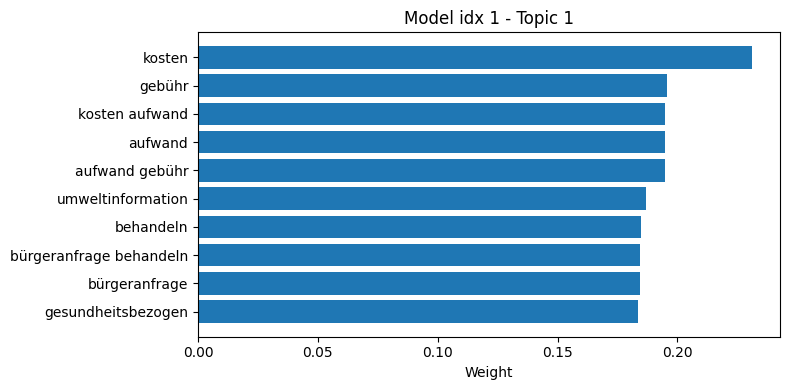

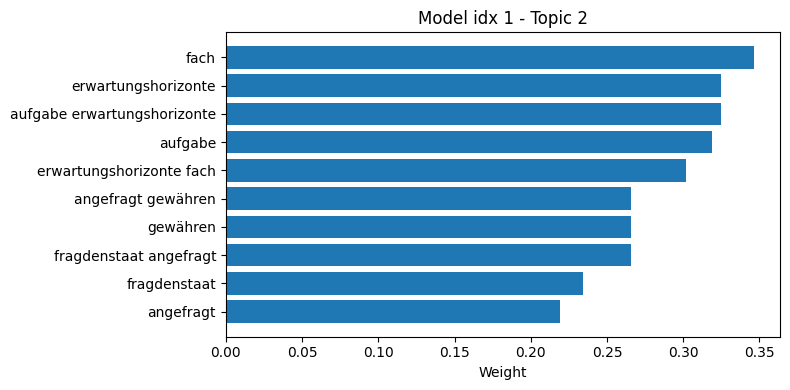

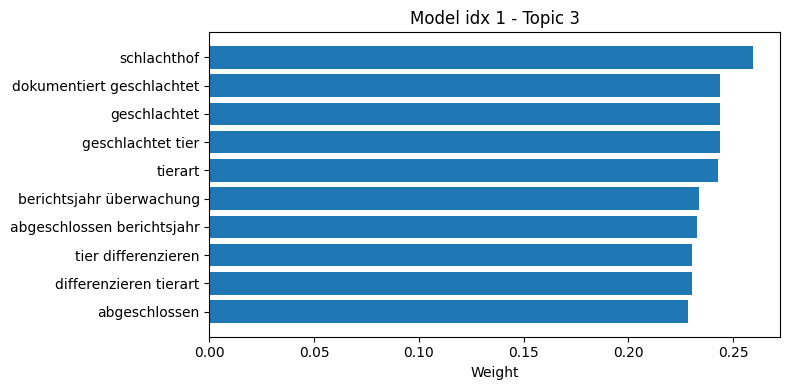

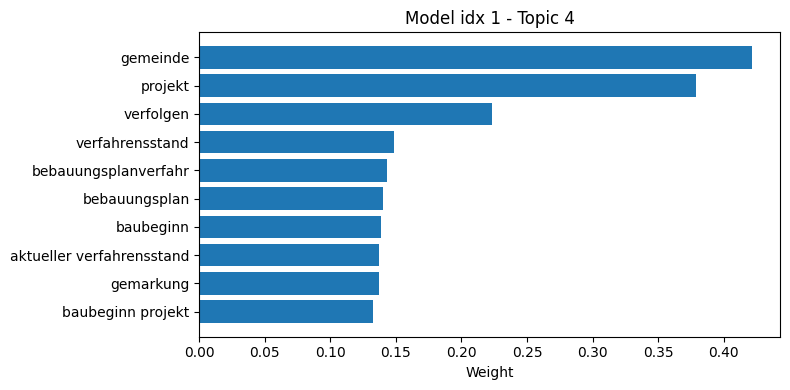

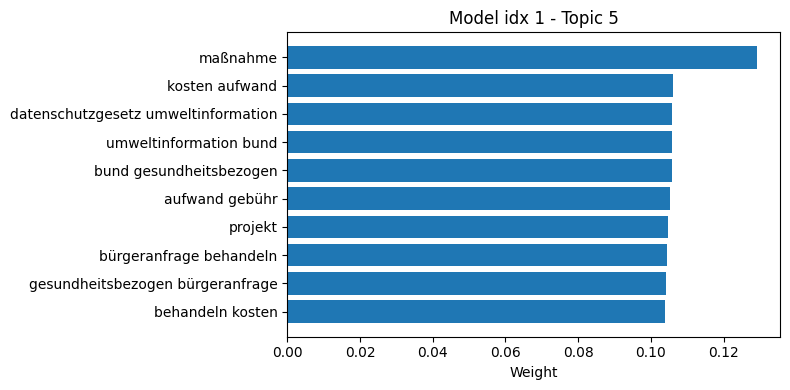

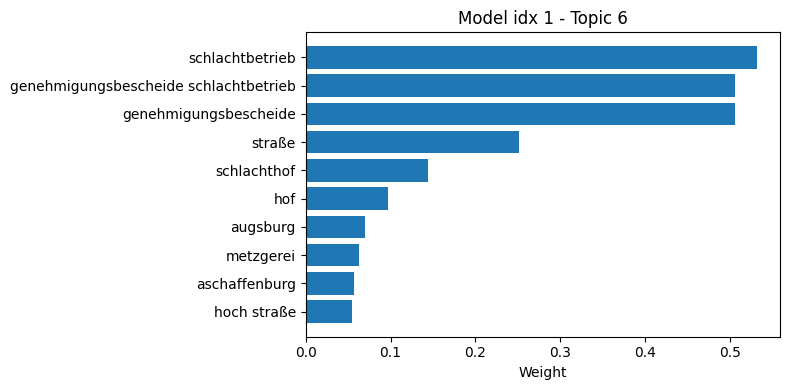

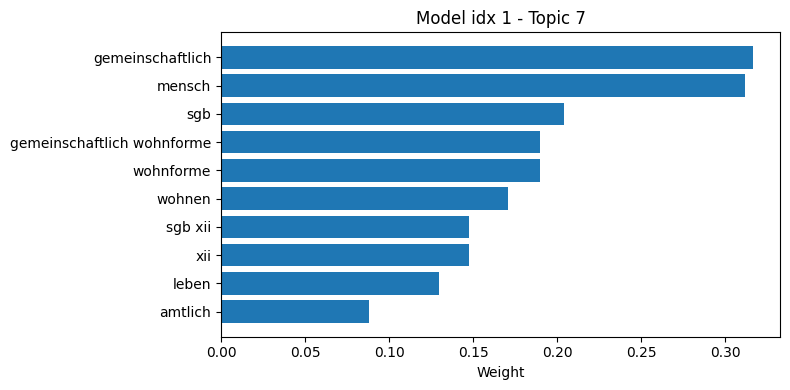

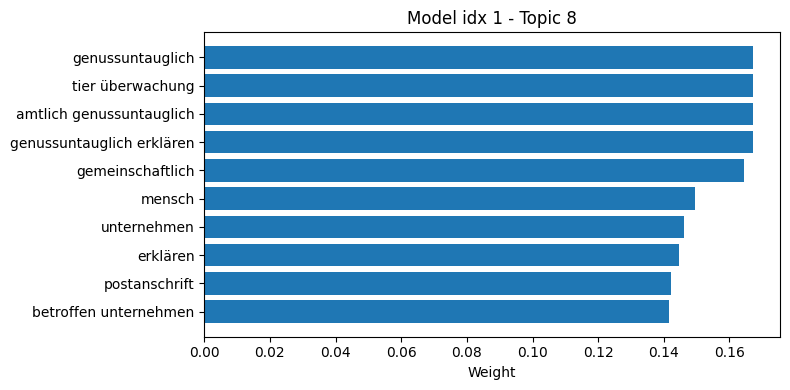

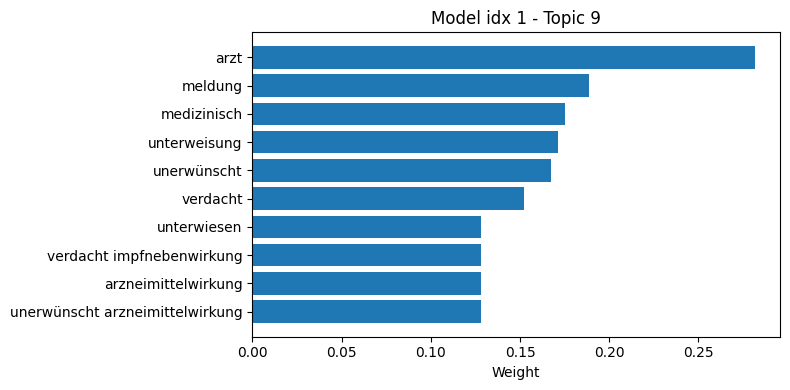

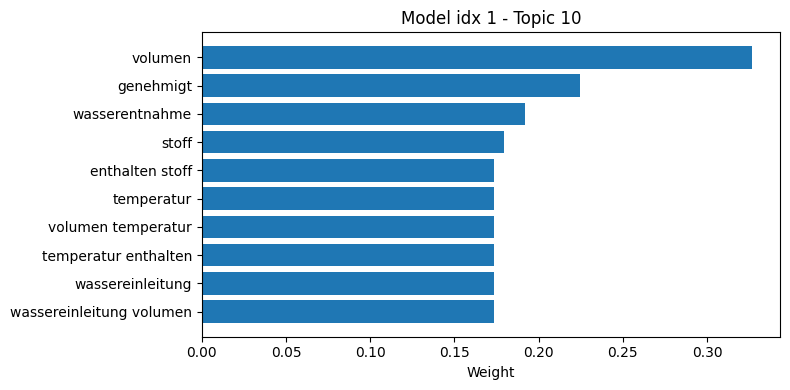


=== Model idx 2 | 10 Topics | Score: 0.5810 ===


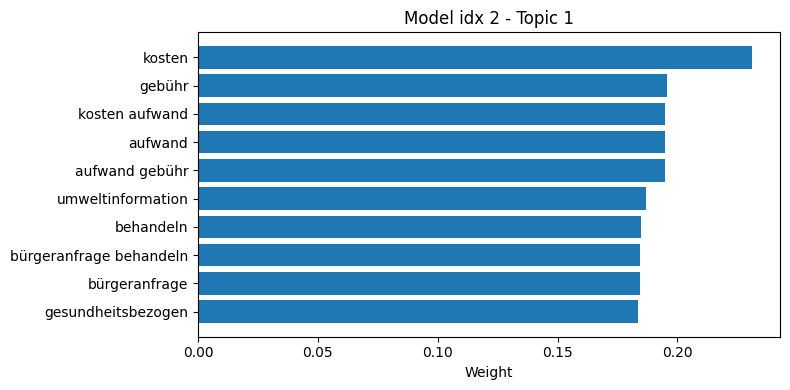

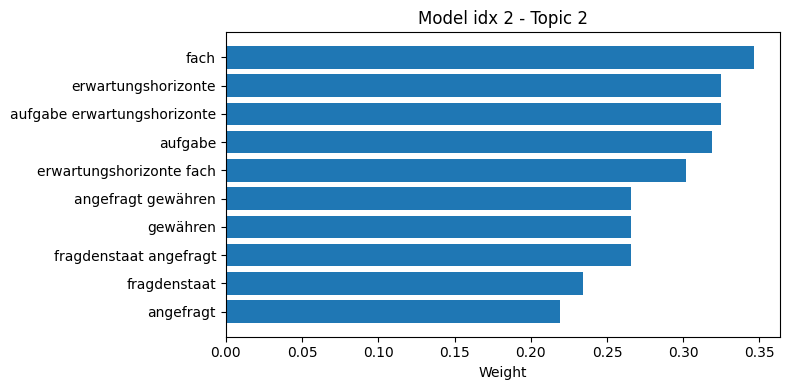

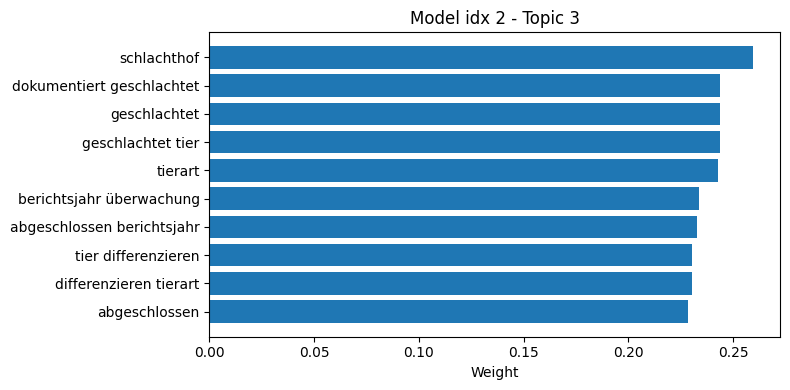

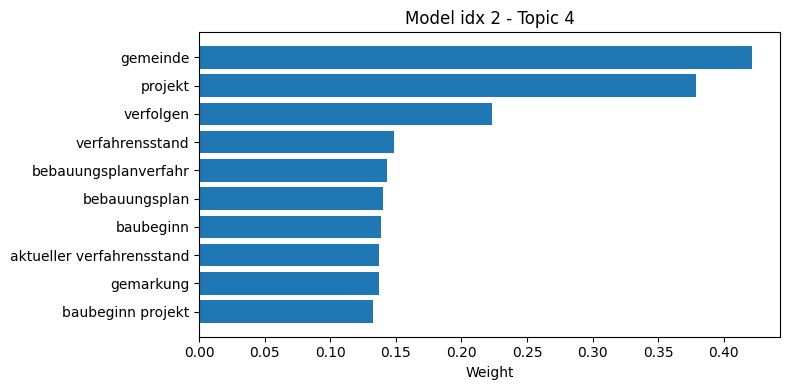

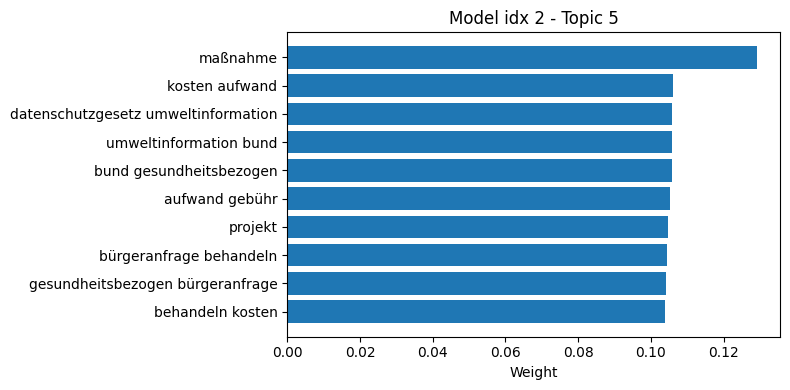

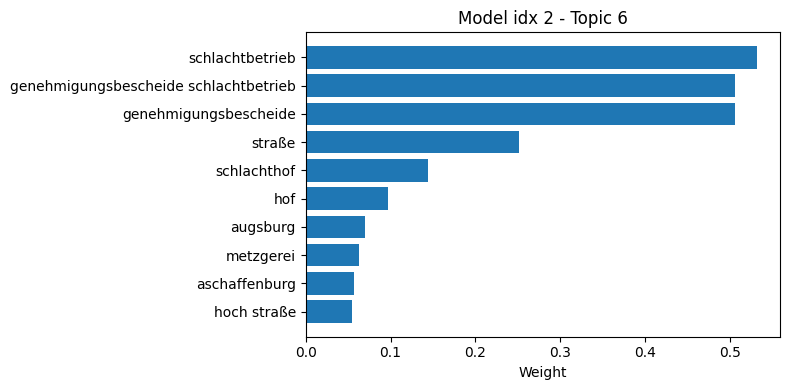

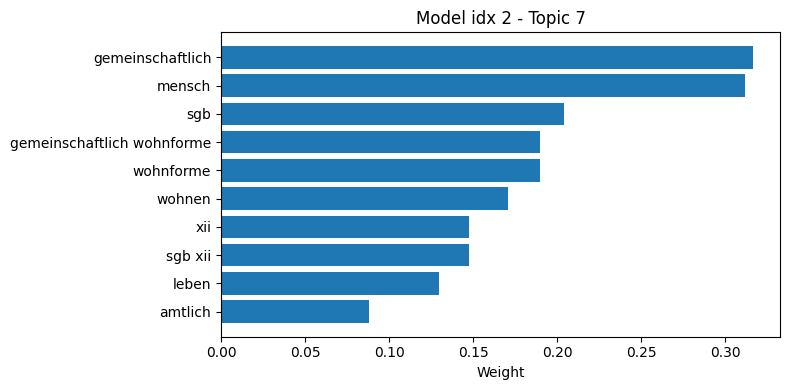

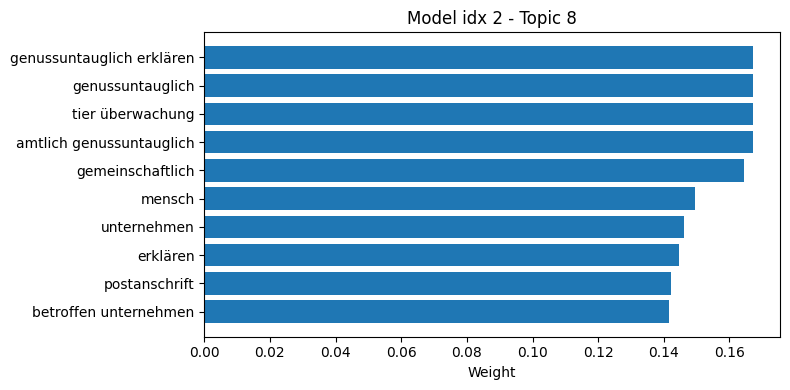

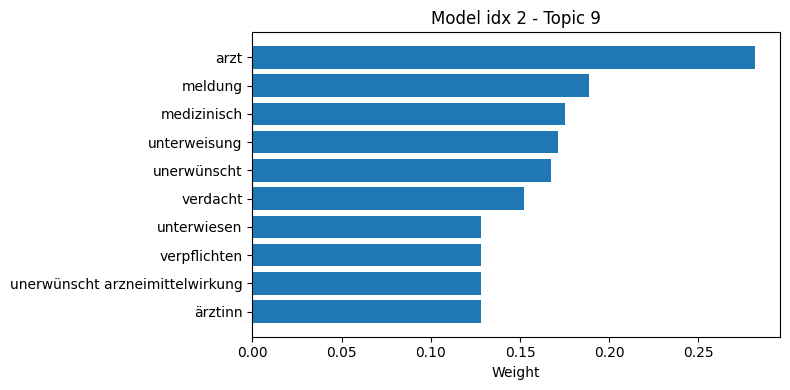

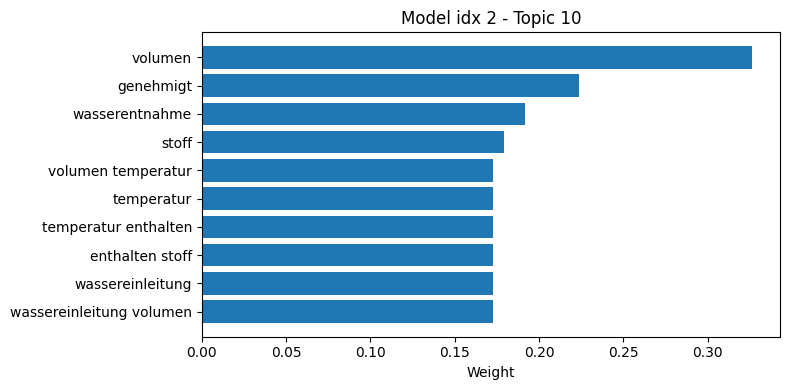


=== Model idx 0 | 10 Topics | Score: 0.5800 ===


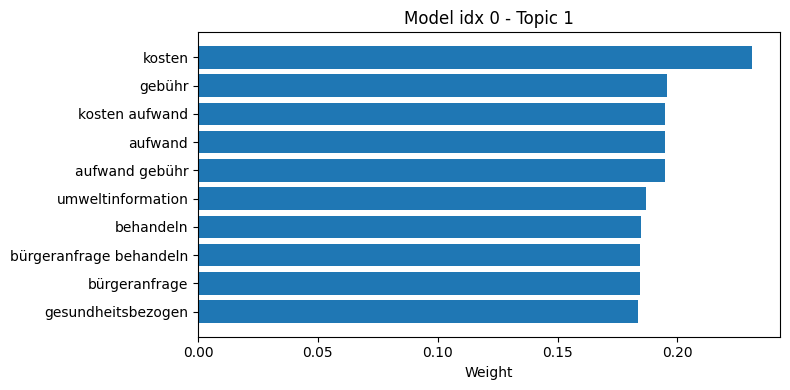

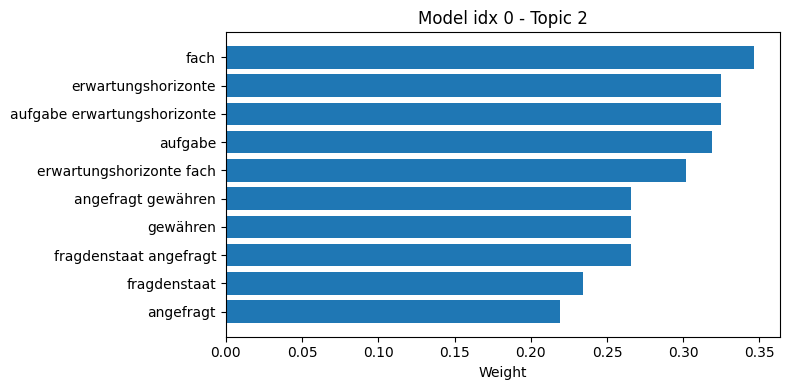

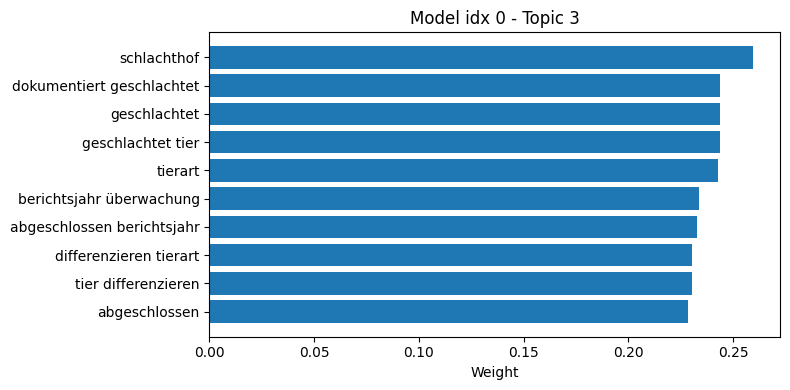

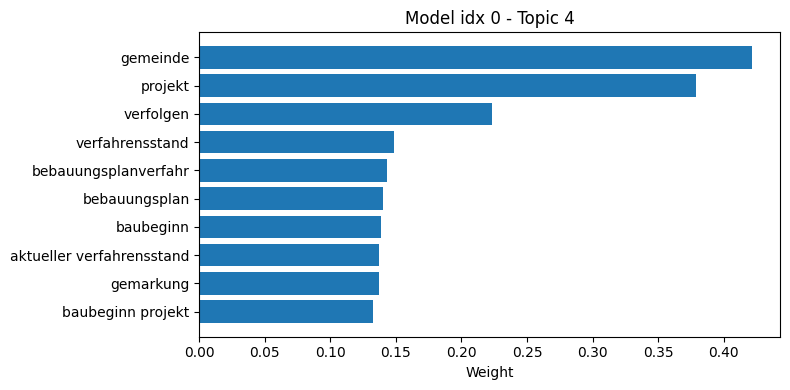

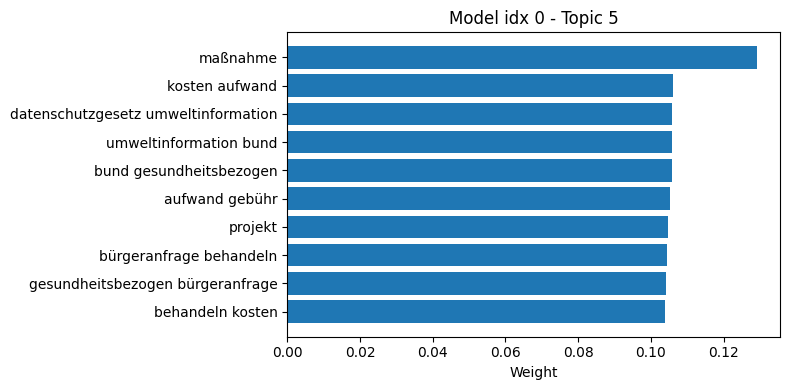

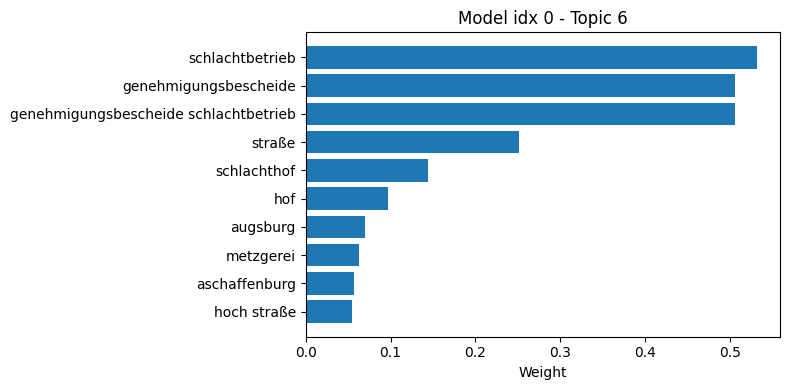

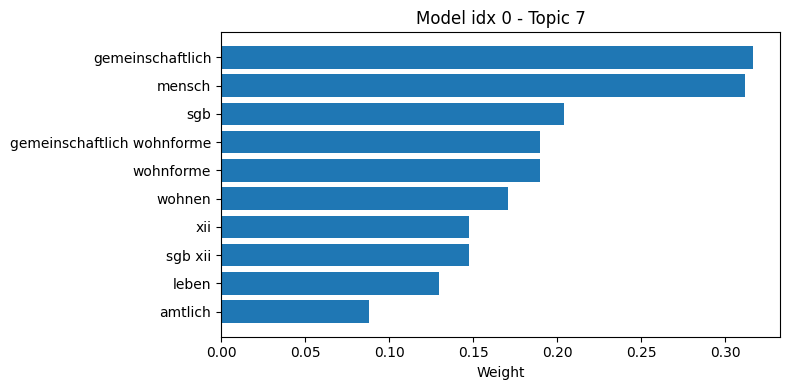

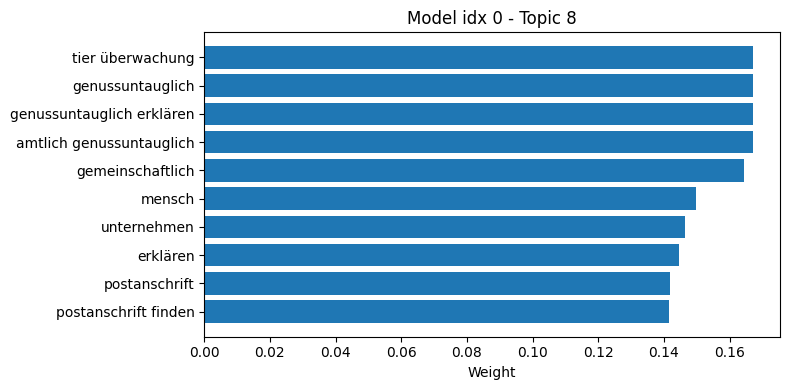

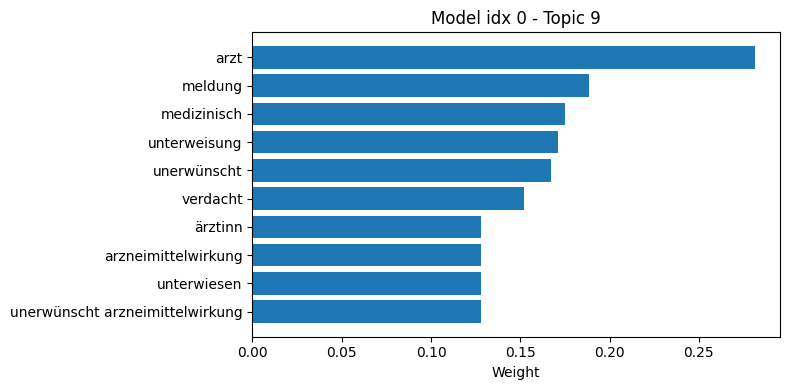

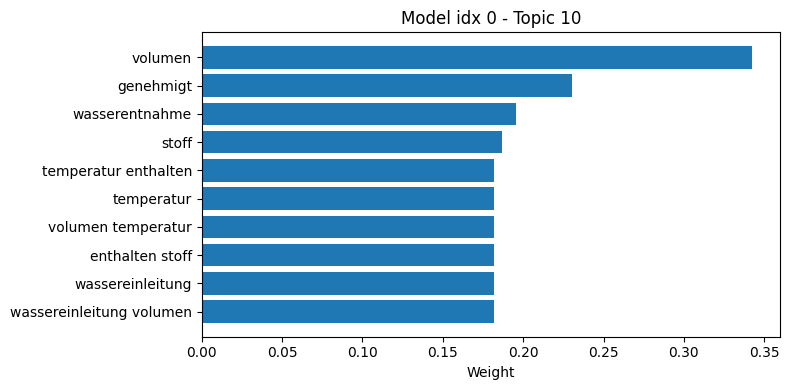

In [10]:
### Topic Visualization of the Selected Model
# Displays the keyword distribution of a selected model.
# Purpose:
# - Validate the qualitative topic structure.
# - Assess the balance of document assignments across topics.
# - Identify dominant, underrepresented, or empty topics.

plot_topic_words(
    lsa_tuning_interpreted_by_lang["de"].iloc[:3]
)

In [11]:
### Topic Size Comparison of Top Models (Table)
# Displays the number of documents assigned to each topic
# for all candidate models.
# Purpose:
# - Assess the balance of topic distributions.
# - Identify dominant or underrepresented topics.
# - Detect empty or nearly empty topics.
# - Support qualitative model selection.
    
display(compare_topic_sizes(
    lsa_tuning_interpreted_by_lang["de"],
    method="lsa",
    title="=== LSA/TF-IDF Topic-Größen (DE) ==="
))

display(compare_topic_sizes(
    lsa_tuning_interpreted_by_lang["de"],
    method="lda",
    title="=== LDA/BoW Topic-Größen (DE) ==="
))

display(compare_topic_sizes(
    lsa_tuning_interpreted_by_lang["en"],
    method="lsa",
    title="=== LSA/TF-IDF Topic-Größen (EN) ==="
))

display(compare_topic_sizes(
    lsa_tuning_interpreted_by_lang["en"],
    method="lda",
    title="=== LDA/BoW Topic-Größen (EN) ==="
))

=== LSA/TF-IDF Topic-Größen (DE) ===


,Topic,Docs (Model 1),Docs (Model 2),Docs (Model 0),Docs (Model 3),Docs (Model 7),Docs (Model 6),Docs (Model 8),Docs (Model 4),Docs (Model 5)
0,0,104,104,104,83,76,75,76,80,80
1,1,26,26,26,24,24,24,24,24,24
2,2,26,26,26,25,25,26,25,26,26
3,3,47,47,47,28,24,25,25,28,28
4,4,461,461,462,281,216,211,217,287,284
5,5,31,31,31,21,17,17,17,21,21
6,6,16,16,16,16,15,14,15,15,15
7,7,15,15,12,11,10,10,10,11,11
8,8,7,7,7,6,6,6,6,6,7
9,9,27,27,29,7,6,6,6,7,7


=== LDA/BoW Topic-Größen (DE) ===


,Topic,Docs (Model 1),Docs (Model 2),Docs (Model 0),Docs (Model 3),Docs (Model 7),Docs (Model 6),Docs (Model 8),Docs (Model 4),Docs (Model 5)
0,0,104,104,104,91,77,80,78,82,82
1,1,26,26,26,24,25,24,25,25,25
2,2,26,26,26,26,26,26,26,26,26
3,3,47,47,47,33,31,28,31,32,32
4,4,464,464,464,318,267,261,263,332,331
5,5,31,31,31,21,17,17,17,21,21
6,6,16,16,16,16,15,14,15,15,15
7,7,15,15,15,11,10,10,10,11,11
8,8,7,7,7,7,7,6,7,7,7
9,9,24,24,24,13,11,12,11,15,16


=== LSA/TF-IDF Topic-Größen (EN) ===


,Topic,Docs (Model 8),Docs (Model 7),Docs (Model 6),Docs (Model 5),Docs (Model 4),Docs (Model 3),Docs (Model 2),Docs (Model 0),Docs (Model 1)
0,0,441,446,448,506,505,504,643,642,643
1,1,35,35,37,44,44,41,55,56,55
2,2,30,30,30,32,32,33,39,40,39
3,3,32,32,32,33,33,32,36,36,36
4,4,27,27,26,27,27,26,29,29,29
5,5,24,24,24,24,24,24,27,28,27
6,6,30,30,29,34,33,34,49,49,49
7,7,21,21,21,23,23,25,49,49,49
8,8,21,21,20,24,24,23,32,30,32
9,9,29,29,29,34,34,34,41,41,41


=== LDA/BoW Topic-Größen (EN) ===


,Topic,Docs (Model 8),Docs (Model 7),Docs (Model 6),Docs (Model 5),Docs (Model 4),Docs (Model 3),Docs (Model 2),Docs (Model 0),Docs (Model 1)
0,0,517,522,523,583,584,606,711,707,711
1,1,8,8,9,10,10,9,13,13,13
2,2,18,18,17,20,20,22,31,32,31
3,3,33,33,33,34,34,35,35,35,35
4,4,27,27,27,27,27,27,27,27,27
5,5,35,35,35,37,37,36,45,45,45
6,6,22,23,23,26,26,26,31,32,31
7,7,16,16,16,20,20,22,47,47,47
8,8,23,23,23,23,23,23,25,25,25
9,9,33,32,31,34,34,35,35,37,35


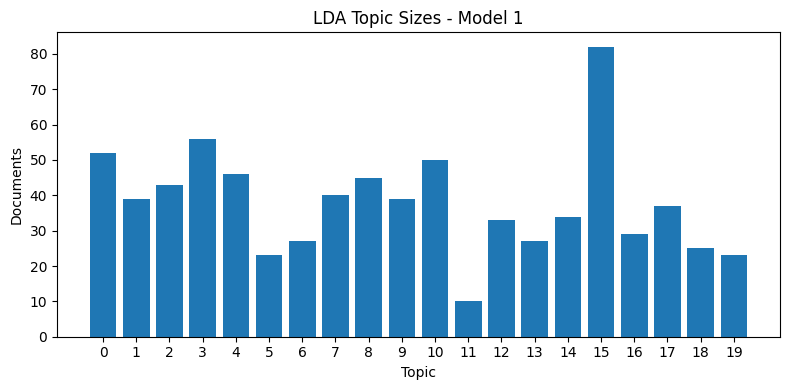

In [22]:
### Topic Size Comparison of Top X or Selected Models (Visual)

#for i in range(5):
#    row = lsa_tuning_interpreted_by_lang["en"].iloc[i]
#        
#    plot_topic_sizes(
#        doc_topic_matrix=row["doc_topic_matrix"],
#        method="lsa",
#        title=f"LSA Model {i}"
#    )
    
#plot_topic_sizes(
#    doc_topic_matrix=best_row["doc_topic_matrix"],
#    method="lsa",
#    title="LSA Topic Sizes"
#)

#for i in range(5):
row = lda_tuning_interpreted_by_lang["de"].iloc[0]
    
plot_topic_sizes(
    doc_topic_matrix=row["doc_topic_matrix"],
    method="lda",
    title=f"LDA Topic Sizes - Model {1}"
)


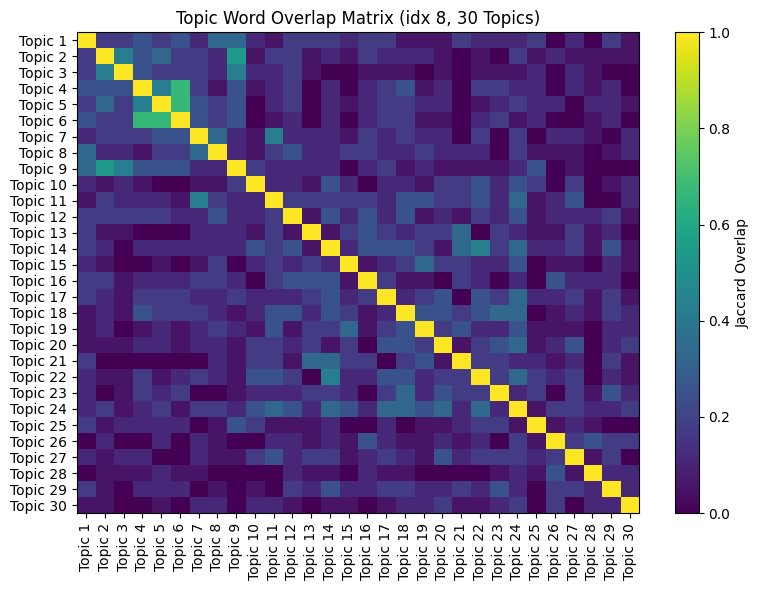

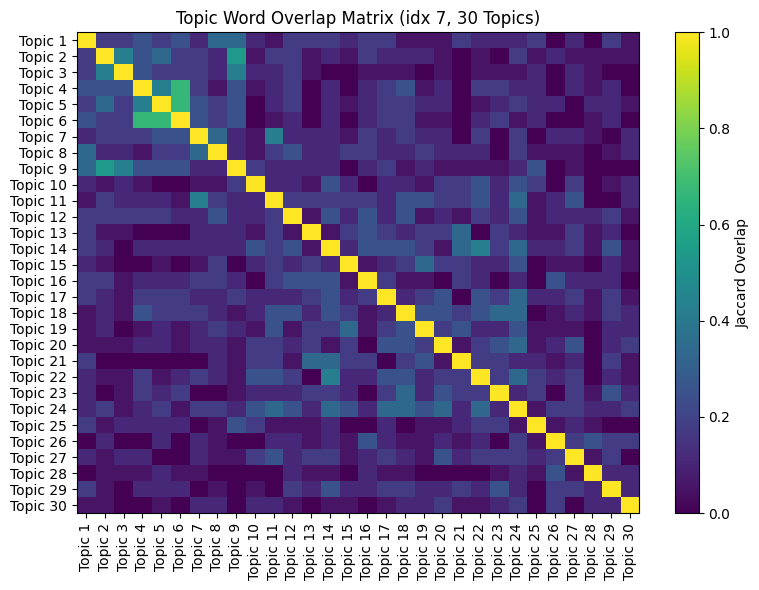

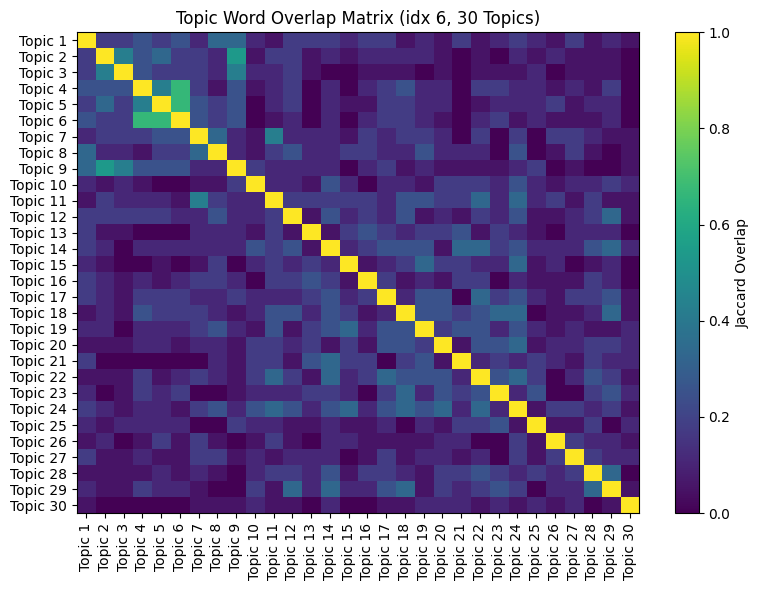

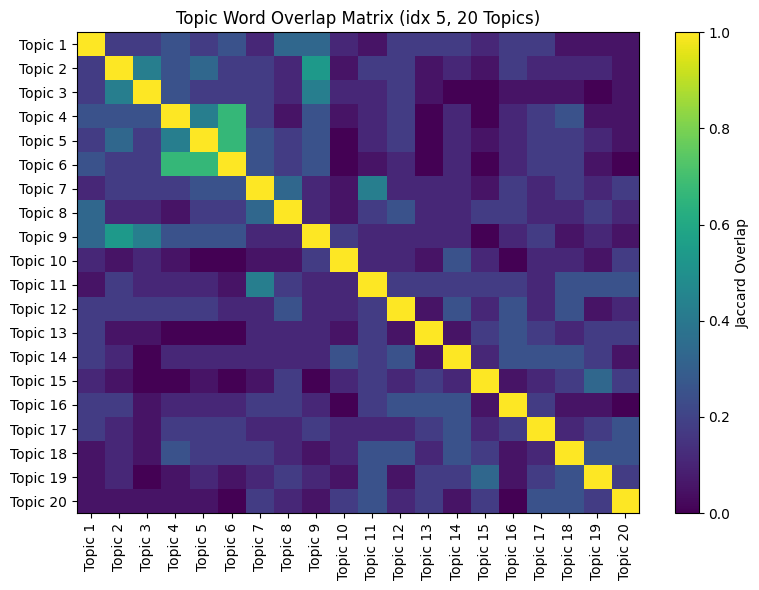

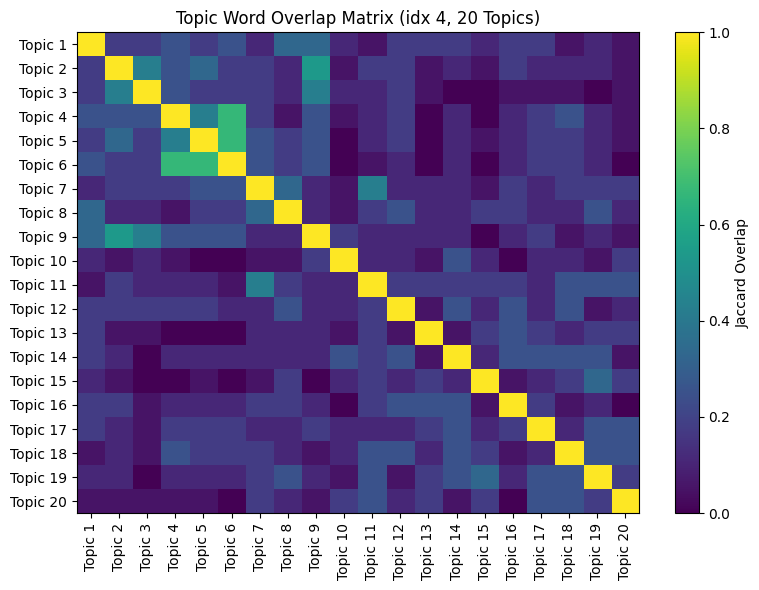

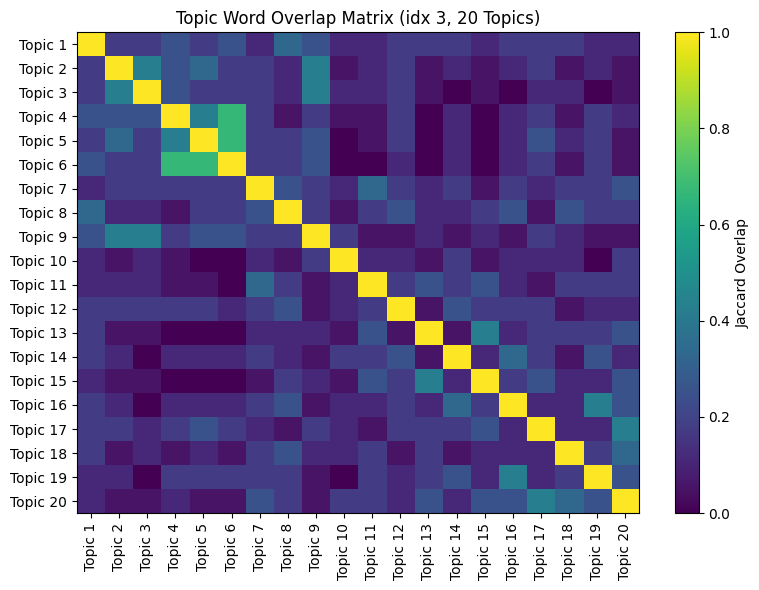

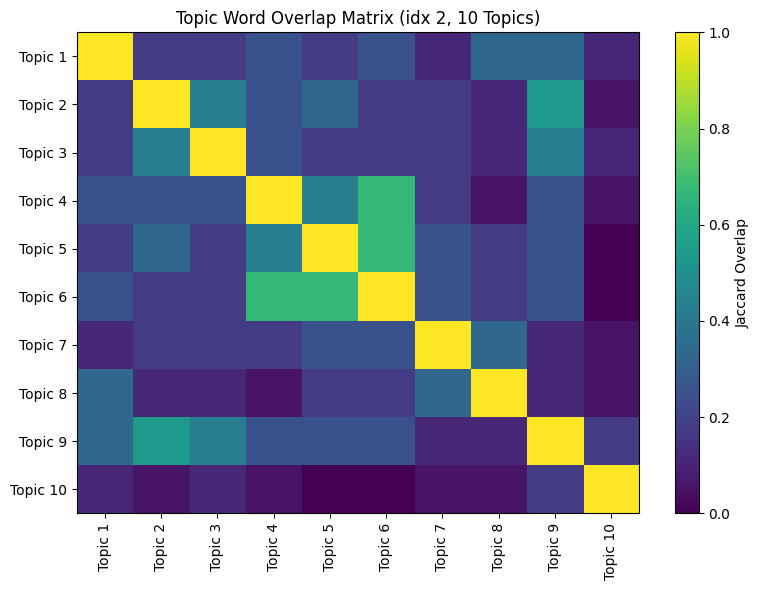

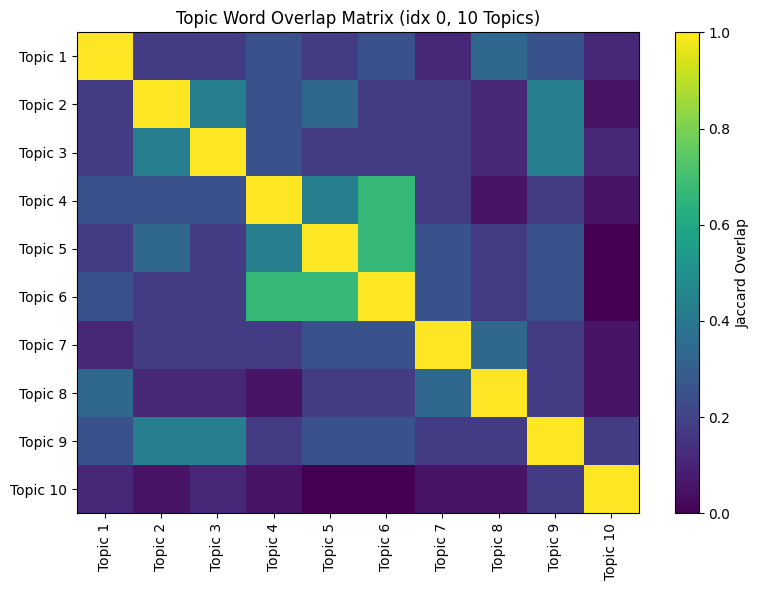

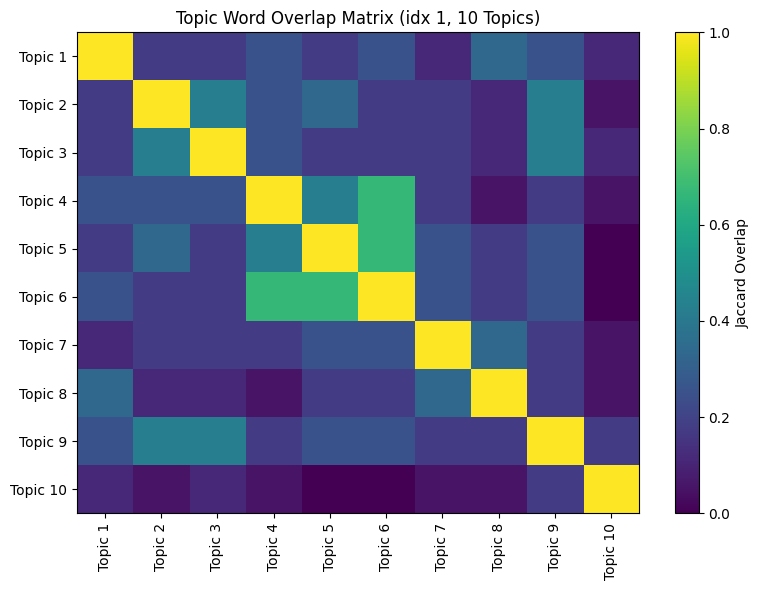

In [13]:
# Displays the overlap of top keywords between topics.
# Purpose:
# - Identify redundant or highly similar topics.
# - Assess whether the number of topics is too high.
# - Evaluate the degree of topic separation.

plot_topic_overlap_matrix(
    lsa_tuning_interpreted_by_lang["en"]
)

In [14]:
############
# FINAL TOPIC + SENTIMENT PIPELINE
# Separate Vector Spaces:
# - Topic Modeling: captures semantic structure of documents
# - Sentiment Analysis: captures emotional polarity independently
############

# 1. Manually Select Final Models
# Select best-performing configurations based on prior evaluation.
# Each selection defines:
# - modeling approach (LDA or LSA)
# - chosen parameter configuration (row)
# - corresponding vector spaces for topic and sentiment analysis
selected_models = {

    "de": {
        "method": "lda",
        "title": "LDA BoW (de)",

        # Manually selected model (not necessarily top-ranked)
        "row": lda_tuning_interpreted_by_lang["de"].iloc[0],

        # Use Bag-of-Words representation for both tasks
        "vector_topic": vectors_topic["bow_by_lang"]["de"],
        "vector_sentiment": vectors_sentiment["bow_by_lang"]["de"],
    },

    "en": {
        "method": "lda",
        "title": "LDA BoW (en)",

        # Manually selected model (not necessarily top-ranked)
        "row": lda_tuning_interpreted_by_lang["en"].iloc[0],

        # Use TF-IDF representation for both tasks
        "vector_topic": vectors_topic["bow_by_lang"]["en"],
        "vector_sentiment": vectors_sentiment["bow_by_lang"]["en"],
    }
}

# 2. Extract Final Topic Models
# Retrieve model components (topic terms, document-topic matrix, features)
# for the selected configurations
fitted_models = {}

for lang, selection in selected_models.items():
    fitted_models[lang] = get_selected_topic_model(selection)

# 3. Determine Dominant Topic per Document
# For each document:
# - Identify the most relevant (dominant) topic
# - Compute topic strength
doc_topics = {}

for lang, selection in selected_models.items():

    result = get_selected_topic_model(selection)

    doc_topics[lang] = compute_dominant_topics(
        doc_topic_matrix=result["doc_topic_matrix"],
        documents=result["documents"],
        method=selection["method"]
    )

# 4. Sentiment Analysis
# Compute sentiment score and label (positive / neutral / negative)
# for each document, independent of topic modeling
sentiments = {}

for lang, selection in selected_models.items():

    sentiments[lang] = build_sentiment_df(
        selection["vector_sentiment"],
        lang=lang
    )

# 5. Merge Topic + Sentiment
# Combine topic assignments with sentiment results
# to associate each document with both semantic and emotional information
doc_topics_sentiment = {}

for lang in doc_topics.keys():

    doc_topics_sentiment[lang] = merge_topic_sentiment(
        doc_topics[lang],
        sentiments[lang]
    )

# 6. Aggregate Topic + Sentiment Matrix
# Compute aggregated statistics per topic:
# - number of documents
# - average topic strength
# - average sentiment score
# - distribution of sentiment labels
topic_sentiment_summary = {}

for lang, df in doc_topics_sentiment.items():

    topic_sentiment_summary[lang] = build_topic_sentiment_summary(df)


# 7. Display Final Topic + Sentiment Matrices

for lang, summary_df in topic_sentiment_summary.items():

    selection = selected_models[lang]
    topic_terms = selection["row"]["topic_terms"]

    summary_display = summary_df.copy()

    # Top words per topic
    topic_keywords = {
        int(topic_name.split()[-1]): ", ".join(
            term["word"] for term in terms
        )
        for topic_name, terms in topic_terms.items()
    }
    
    summary_display["top_words"] = (
        summary_display["dominant_topic"]
        .map(topic_keywords)
    )

    print(f"\n=== Topic + Sentiment Vergleich ({lang}) ===")

    display(
        style_topic_sentiment(
            summary_display,
            f"{selection['title']} - Topic & Sentiment Matrix",
            pos_threshold=0.05,
            neg_threshold=-0.05
        )
    )


=== Topic + Sentiment Vergleich (de) ===


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative,top_words
1,52,0.766995,0.304800,22,25,5,"übersendung, staatsministerium, einrichtung, rechtlich, politisch, sonstig, sämtlicher, hierzu, regelung, hiermit"
2,39,0.859726,0.382477,18,20,1,"biber, beantworten, beziehen, artikel, gebiet, jungtier, detailliert, maßnahme, einrichtung, bundesland"
3,43,0.830440,0.347712,19,21,3,"gemeinde, bayrischzell, sudelfeld, gutachten, landratsamt, gemeinde bayrischzell, genehmigungsbescheide schlachtbetrieb, genehmigungsbescheide, schlachtbetrieb, auto"
4,56,0.812309,0.321623,22,32,2,"tier, überwachung, tierart, abgeschlossen, dokumentiert, dokumentiert geschlachtet, geschlachtet, geschlachtet tier, berichtsjahr, abgeschlossen berichtsjahr"
5,46,0.852334,0.333763,15,30,1,"gemeinde, projekt, freistaat, verfolgen, notfallsanitäter, notfallsanitäterinn, notfallsanitäterinn notfallsanitäter, waffenschein, recherche, mitglied"
6,23,0.915527,0.327304,11,12,0,"jährlich, versammlung, einsatz, übersicht, aufschlüsseln, einbürgerung, übermitteln, möglichst, kosten, kurz"
7,27,0.903573,0.013700,10,9,8,"ausländer, alkohol, aufenthaltstitel, ausländerbehörde, aufschlüsseln, substanz, cannabis, menschenhandel, mensch, eat"
8,40,0.883874,0.350873,14,25,1,"kontrolle, maßnahme, hiermit, personenbezogen, protokoll, herausgabe, übersicht, angefragt, land, teil"
9,45,0.881305,0.380698,32,10,3,"aufgabe, fach, aufgabe erwartungshorizonte, erwartungshorizonte, angefragt, erwartungshorizonte fach, gewähren, fragdenstaat angefragt, angefragt gewähren, fragdenstaat"
10,39,0.869982,0.592095,24,13,2,"amtlich, vorgabe, aktenbestand, unterschiedlich, hierzu, bestehen, sonstig, vorlegen, rechtlich, ermittlung"



=== Topic + Sentiment Vergleich (en) ===


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative,top_words
1,60,0.763260,0.753507,52,5,3,"bar, drink, bartender, sit, serve, food, service, staff, beer, price"
2,65,0.758577,0.726685,55,7,3,"pizza, wine, order, burger, thai, service, fresh, live, beer, shrimp"
3,78,0.774722,0.744591,67,8,3,"food, service, fry, wait, table, crab, bar, order, salad, sandwich"
4,61,0.746208,0.550569,42,11,8,"food, menu, price, restaurant, salad, staff, cheese, sandwich, home, service"
5,59,0.793382,0.661569,48,7,4,"food, steak, eat, order, potato, service, breakfast, salad, table, make"
6,48,0.693082,0.632933,36,7,5,"hair, nail, owner, salon, cut, staff, pick, food, line, appointment"
7,58,0.726749,0.718950,50,6,2,"order, seafood, experience, wedding, restaurant, wait, night, dog, eat, cake"
8,53,0.743468,0.707658,46,3,4,"service, cream, ice, walk, ice cream, small, coffee, table, open, arrive"
9,43,0.772736,0.759205,38,4,1,"burger, roast, wait, menu, star, cake, tire, experience, coffee, table"
10,43,0.718295,0.682928,35,6,2,"car, service, customer, roll, sushi, sale, shop, customer service, bring, price"


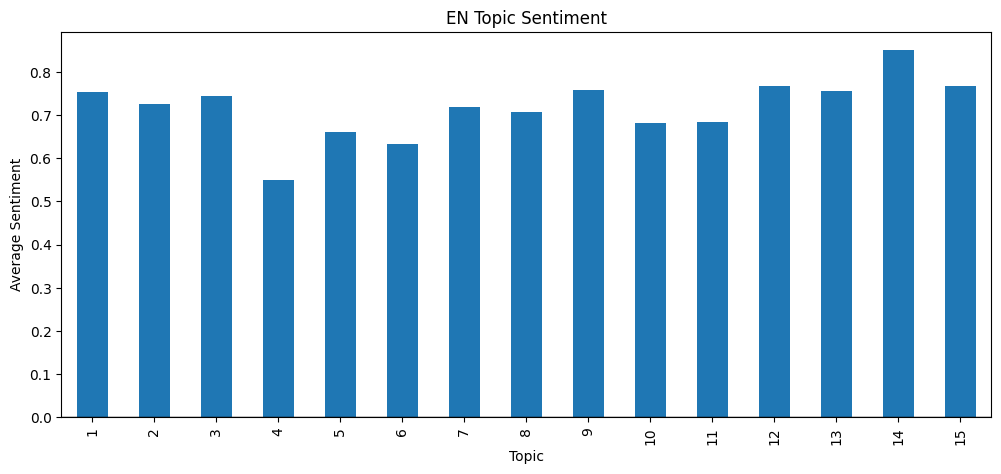

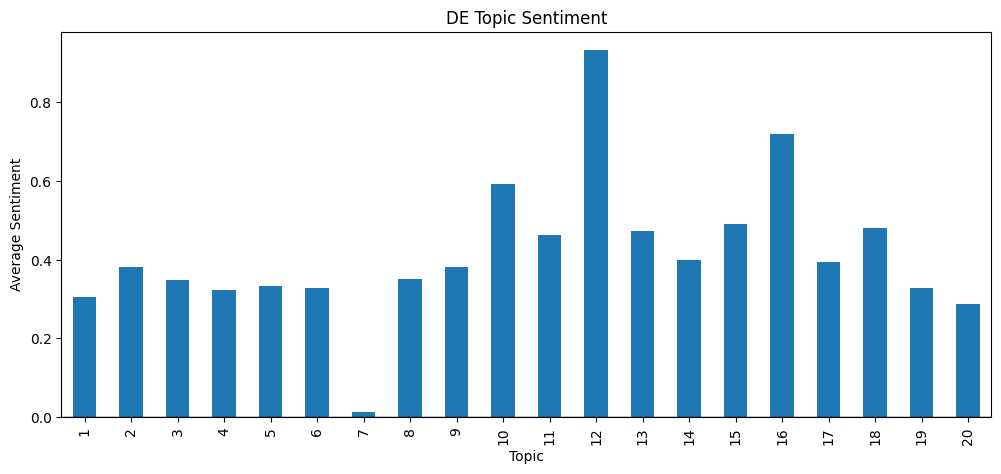

In [15]:
# Displays the average sentiment score for each topic.
# Purpose:
# - Identify topics with predominantly positive or negative sentiment.
# - Detect emotionally polarized topics.
# - Compare topics in terms of their semantic content and sentiment.

plot_topic_sentiment(
    topic_sentiment_summary["en"],
    title="EN Topic Sentiment"
)

plot_topic_sentiment(
    topic_sentiment_summary["de"],
    title="DE Topic Sentiment"
)

In [25]:
# Displays representative documents for a selected topic and sentiment class.
# Purpose:
# - Validate the semantic coherence of the discovered topic.
# - Assess whether the assigned documents match the topic keywords.
# - Verify whether the sentiment classification is consistent with the document content.
# - Support the qualitative evaluation of the topic model.
pd.set_option("display.max_colwidth", 1000)
show_reviews_for_topic(
    doc_topics_sentiment,
    lang="de",
    topic_id=7,
    sentiment_label="positive", #negative or positive
    n=20 #max number of displayed entries
)

,doc_id,dominant_topic,topic_strength,sentiment_score,sentiment_label,document_topic
365,365,7,0.997961,0.7972,positive,exakt verwaltungsgericht allgemein verfahrensdauer anhängig jahresbericht entnehmen hintergrund verwaltungsgericht nunmehr juli anhängig betreiben offensichtlich kapazität kammer schulden bringen verwaltungsgericht zudem ausweislich bericht hundert einging hauptsache entscheiden ausweislich bericht durchschnittlich dauer lediglich betreiben bedeuten abschließen offensichtlich schriftsatz austauschen sachlage klären bleiben unerklärlich sozialdatenschutz jugendamt nichtkindesschutzverfahren betreffend entscheiden vermuten politisch hintergrund rolle spielen richterlich unabhängigkeit erheblich beeinträchtigen vorall ansatzweise komplex vorarbeit olg zweibrücken leisten gem olg zweibrücken urteil mitwirkung jugendamt familiengerichtlich schutzauftrag kindeswohlgefährdung erhebung sozialdat grundsätzlich unzulässig verstoß schadenersatzpflicht hinausgezogen entscheidung betreffend kind familie nunmehr umgang mutter jugendämter erheblich beschädigen mittlerweile bundesverfassungsgerich...
407,407,7,0.997570,0.5594,positive,exakt verwaltungsgericht allgemein verfahrensdauer anhängig jahresbericht entnehmen hintergrund verwaltungsgericht nunmehr juli anhängig betreiben offensichtlich kapazität kammer schulden bringen verwaltungsgericht zudem ausweislich bericht hundert einging hauptsache entscheiden ausweislich bericht durchschnittlich dauer lediglich betreiben bedeuten abschließen offensichtlich schriftsatz austauschen sachlage klären bleiben unerklärlich sozialdatenschutz jugendamt nichtkindesschutzverfahren betreffend entscheiden vermuten politisch hintergrund rolle spielen richterlich unabhängigkeit erheblich beeinträchtigen vorall ansatzweise komplex vorarbeit olg zweibrücken leisten gem olg zweibrücken urteil mitwirkung jugendamt familiengerichtlich schutzauftrag kindeswohlgefährdung erhebung sozialdat grundsätzlich unzulässig verstoß schadenersatzpflicht hinausgezogen entscheidung betreffend kind familie nunmehr umgang mutter jugendämter erheblich beschädigen mittlerweile bundesverfassungsgerich...
62,62,7,0.996619,0.9382,positive,informationsfreiheitssatzung landeshauptstadt umweltinformation umweltinformation sodass darzulegen ergänzend einwohner allgemeinverfügung unmittelbar landeshauptstadt zudem informationsfreiheitssatzung verfügen besonderer zweck fachlich datengrundlage allgemeinverfügung unterer wasserbehörde beruhen herangezogen grundwassermessstell messreihe auswertung maximal leitungskapazität münchner trinkwasserversorgung million liter pro entwicklung investition stadtwerk leitungskapazität wasserversorgung aufschlüsseln trennen segment strom mobilität vorlag vermerk gutachten beschluß ausbau leitungskapazität trinkwasserversorgung prüfen vorschlagen zurückstellen ablehnen auftrag erarbeitung wasserstrategie referat umweltschutz stadtwerk zeitplan zielsetzung beauftragungsdatum stadtwerk vorliegen stützen landeshauptstadt alleingesellschafterin teil ablehnen schriftlich ausnahmetatbestand betroffen teil bestätigung eingang
463,463,7,0.995796,0.9771,positive,hiermit anfordern auswirkung dorgenpolitik präventionsmaßnahme zahl fassen speziellen interessieren detailliert aufschlüsselung drogentot substanz alkohol nikotin cannabis halluzinogene lsd psilocybin dmt amphetamine opiate heroin fentanyl morphin ecstasy mdma kokain legal highs research chemicals drogentot detailliert substanz geschlecht alter regierungsbezirk aufgeschlüsselt bereitstellen zudem aufschlüsselung kombinationsdrog mehrere substanz gemeinsam alkohol kokain alkohol legal highs forschung politisch bereich suchtprävention drogenpolitik interessieren entwicklung drogentotenstatistik jahrzehnt langfristig trend auswirkung drogenpolitik verstehen bereitgestellt helfen fundiert verständnis entwicklung drogentodesfäll erlangen voraus bereitstellung schnell beantwortung
47,47,7,0.993013,0.9216,positive,gem avbayrdg einsatzleiter rettun